# Sports Scraper — EDA
Exploratory analysis of scraped posts stored in MongoDB.

In [17]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pymongo', 'wordcloud', 'seaborn', 'pandas', 'matplotlib'])
print('Done')

Done


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from pymongo import MongoClient

%matplotlib inline

client = MongoClient('mongodb://localhost:27017/')
db = client['sports_scraper']
collection = db['posts']

df = pd.DataFrame(list(collection.find()))
if df.empty:
    print('No data in DB. Run a search and save first!')
else:
    if '_id' in df.columns:
        df.drop(columns=['_id'], inplace=True)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    print(f'Total posts: {len(df)}')
    print(df['source'].value_counts().to_dict())
    df.head()

Total posts: 75
{'youtube': 45, 'bbc': 30}


## Duplicate Detection

Total posts: 75
Exact duplicate titles: 19
Titles appearing in both sources: 0

No cross-source duplicates found.


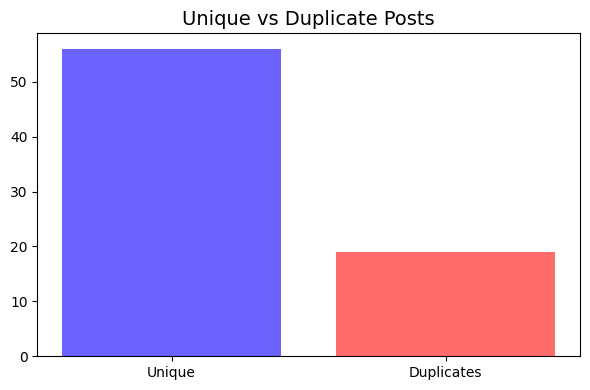

In [2]:
if not df.empty and 'title' in df.columns:
    # כפילויות מדויקות - אותו title בדיוק
    exact_dupes = df[df.duplicated(subset=['title'], keep=False)]

    # כפילויות בין מקורות - אותו title ב-YouTube וגם ב-BBC
    cross_source_dupes = df[df.duplicated(subset=['title'], keep=False)] \
        .groupby('title')['source'].nunique()
    cross_source_dupes = cross_source_dupes[cross_source_dupes > 1]

    print(f"Total posts: {len(df)}")
    print(f"Exact duplicate titles: {df.duplicated(subset=['title']).sum()}")
    print(f"Titles appearing in both sources: {len(cross_source_dupes)}")

    if len(cross_source_dupes) > 0:
        print("\nTitles found in multiple sources:")
        dupes_df = df[df['title'].isin(cross_source_dupes.index)][['title', 'source']].sort_values('title')
        display(dupes_df)
    else:
        print("\nNo cross-source duplicates found.")

    # ויזואליזציה
    if df.duplicated(subset=['title']).sum() > 0:
        dup_counts = {'Unique': len(df) - df.duplicated(subset=['title']).sum(),
                      'Duplicates': df.duplicated(subset=['title']).sum()}
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(dup_counts.keys(), dup_counts.values(), color=['#6C63FF', '#FF6B6B'], edgecolor='none')
        ax.set_title('Unique vs Duplicate Posts', fontsize=14)
        plt.tight_layout()
        plt.show()

## Posts by Source

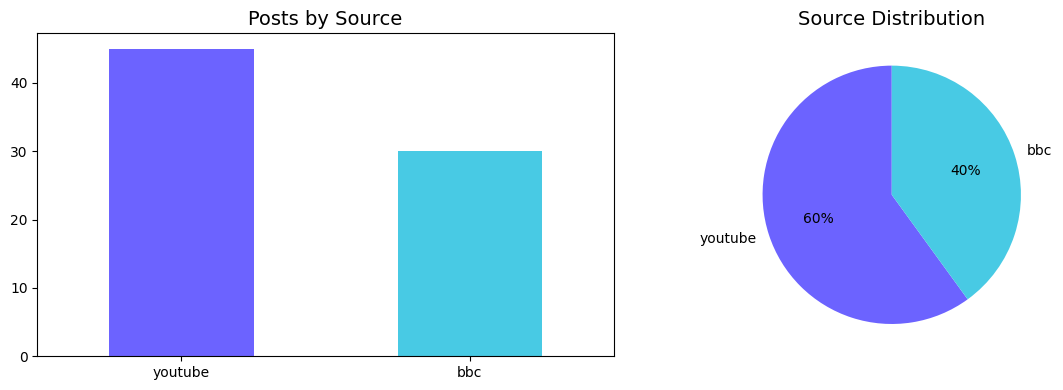

In [4]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    source_counts = df['source'].value_counts()
    colors = ['#6C63FF', '#48CAE4']
    source_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
    axes[0].set_title('Posts by Source', fontsize=14)
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=0)

    # Pie chart
    axes[1].pie(source_counts, labels=source_counts.index, autopct='%1.0f%%',
                colors=colors, startangle=90)
    axes[1].set_title('Source Distribution', fontsize=14)

    plt.tight_layout()
    plt.show()

## Sentiment Analysis

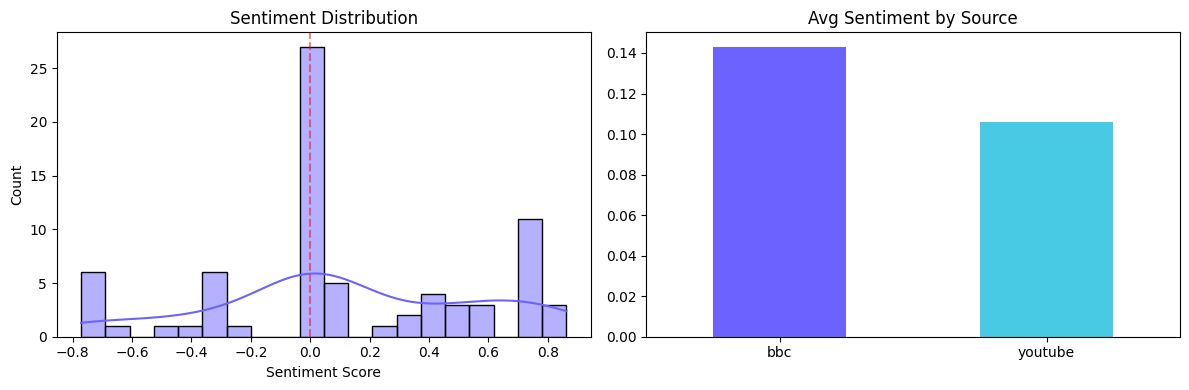

Positive: 35 | Negative: 16 | Neutral: 24


In [5]:
if not df.empty and 'sentiment' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution
    sns.histplot(df['sentiment'], bins=20, kde=True, ax=axes[0], color='#6C63FF')
    axes[0].set_title('Sentiment Distribution')
    axes[0].set_xlabel('Sentiment Score')
    axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

    # Sentiment by source
    df.groupby('source')['sentiment'].mean().plot(kind='bar', ax=axes[1],
                                                   color=['#6C63FF', '#48CAE4'], edgecolor='none')
    axes[1].set_title('Avg Sentiment by Source')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    pos = (df['sentiment'] > 0).sum()
    neg = (df['sentiment'] < 0).sum()
    neu = (df['sentiment'] == 0).sum()
    print(f'Positive: {pos} | Negative: {neg} | Neutral: {neu}')

## Top Titles by Sentiment

In [6]:
if not df.empty and 'sentiment' in df.columns and 'title' in df.columns:
    top_pos = df.nlargest(5, 'sentiment')[['title', 'source', 'sentiment']]
    top_neg = df.nsmallest(5, 'sentiment')[['title', 'source', 'sentiment']]

    print("Top 5 Most POSITIVE titles:")
    display(top_pos.reset_index(drop=True))

    print("\nTop 5 Most NEGATIVE titles:")
    display(top_neg.reset_index(drop=True))

Top 5 Most POSITIVE titles:


,title,source,sentiment
0,Could have been the BEST Champions League assi...,youtube,0.8633
1,Huge win in the first leg | Atalanta Bergamo -...,youtube,0.8591
2,Champions league winner 2026 🥶☠️ (+2M),youtube,0.8020
3,"New puppy, getting engaged and a title - Sabal...",bbc,0.7717
4,"New puppy, getting engaged and a title - Sabal...",bbc,0.7717



Top 5 Most NEGATIVE titles:


,title,source,sentiment
0,Spurs answer Tudor's call with show of fight i...,bbc,-0.7717
1,Spurs answer Tudor's call with show of fight i...,bbc,-0.7717
2,Spurs answer Tudor's call with show of fight i...,bbc,-0.7717
3,NBA &quot;BREAKING RECORDS!!!&quot; 😱 MOMENTS,youtube,-0.7701
4,NBA &quot;MOST IMPOSSIBLE&quot; 😱 2026 MOMENTS,youtube,-0.7003


## Top Keywords

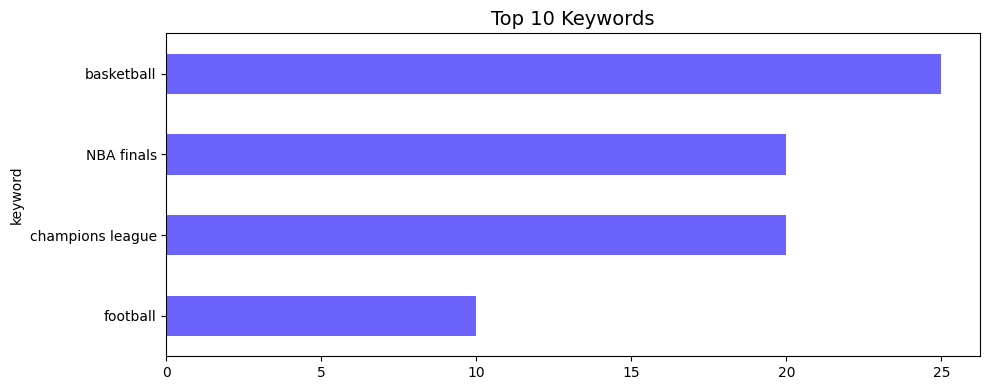

In [7]:
if not df.empty and 'keyword' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    kw_counts = df['keyword'].value_counts().head(10)
    kw_counts.plot(kind='barh', ax=ax, color='#6C63FF', edgecolor='none')
    ax.set_title('Top 10 Keywords', fontsize=14)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Word Cloud from Titles

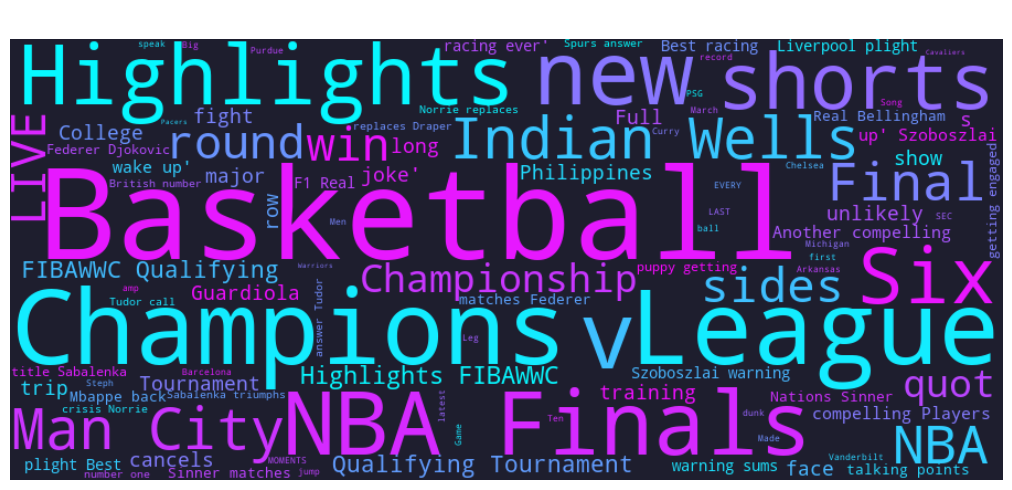

In [8]:
if not df.empty and 'title' in df.columns:
    text = ' '.join(df['title'].dropna().tolist())
    if text.strip():
        wc = WordCloud(width=900, height=400, background_color='#1e1e2e',
                       colormap='cool', max_words=100).generate(text)
        plt.figure(figsize=(12, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud — Post Titles', fontsize=14, color='white', pad=10)
        plt.tight_layout()
        plt.show()

## Sentiment by Keyword

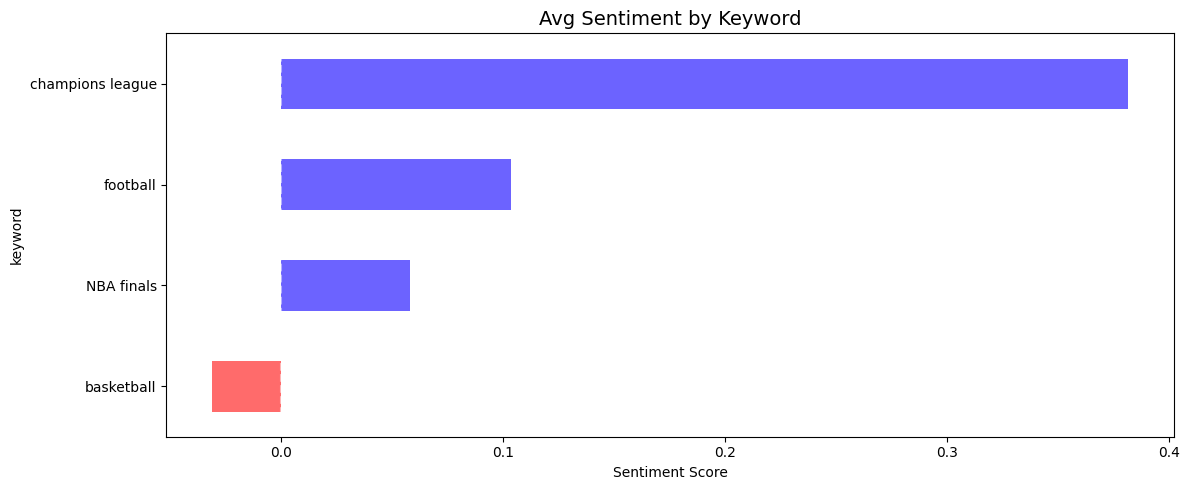

Most positive keyword: champions league (0.38)
Most negative keyword: basketball (-0.03)


In [9]:
if not df.empty and 'sentiment' in df.columns and 'keyword' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    kw_sentiment = df.groupby('keyword')['sentiment'].mean().sort_values()
    colors = ['#FF6B6B' if v < 0 else '#6C63FF' for v in kw_sentiment.values]
    kw_sentiment.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
    ax.axvline(0, color='white', linestyle='--', alpha=0.5)
    ax.set_title('Avg Sentiment by Keyword', fontsize=14)
    ax.set_xlabel('Sentiment Score')
    plt.tight_layout()
    plt.show()
    print("Most positive keyword:", kw_sentiment.idxmax(), f"({kw_sentiment.max():.2f})")
    print("Most negative keyword:", kw_sentiment.idxmin(), f"({kw_sentiment.min():.2f})")

## Posts by Day of Week

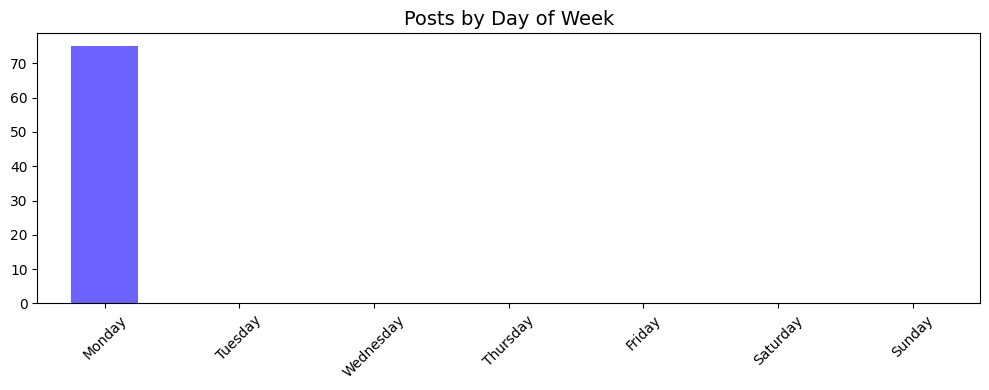

Most active day: Monday (75 posts)


In [10]:
if not df.empty and 'date' in df.columns:
    df_days = df.dropna(subset=['date']).copy()
    df_days['day_of_week'] = df_days['date'].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df_days['day_of_week'].value_counts().reindex(day_order, fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 4))
    day_counts.plot(kind='bar', ax=ax, color='#6C63FF', edgecolor='none')
    ax.set_title('Posts by Day of Week', fontsize=14)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print("Most active day:", day_counts.idxmax(), f"({day_counts.max()} posts)")

## Title Length Analysis

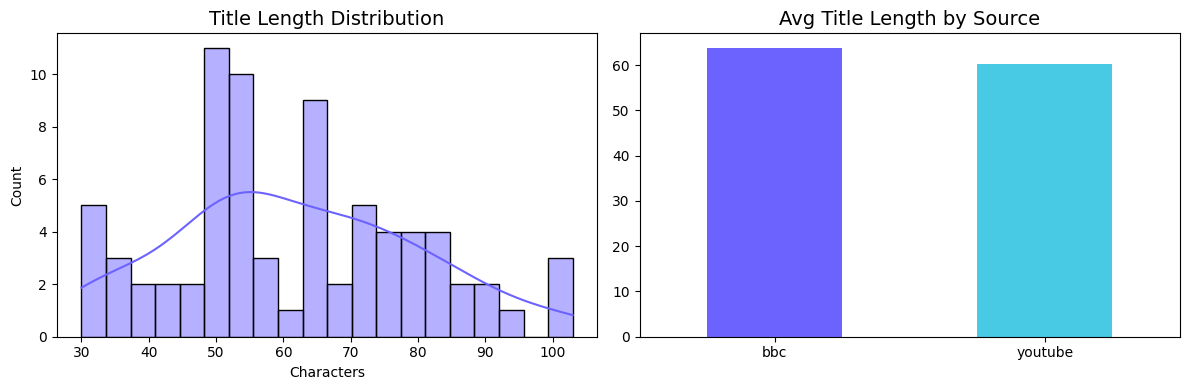

Avg title length: 62 chars
Longest title: 103 chars
Shortest title: 30 chars


In [11]:
if not df.empty and 'title' in df.columns:
    df['title_length'] = df['title'].dropna().apply(len)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # התפלגות אורך כותרת
    sns.histplot(df['title_length'].dropna(), bins=20, kde=True, ax=axes[0], color='#6C63FF')
    axes[0].set_title('Title Length Distribution', fontsize=14)
    axes[0].set_xlabel('Characters')

    # אורך לפי מקור
    if 'source' in df.columns:
        df.groupby('source')['title_length'].mean().plot(kind='bar', ax=axes[1],
            color=['#6C63FF', '#48CAE4'], edgecolor='none')
        axes[1].set_title('Avg Title Length by Source', fontsize=14)
        axes[1].set_xlabel('')
        axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
    print(f"Avg title length: {df['title_length'].mean():.0f} chars")
    print(f"Longest title: {df['title_length'].max()} chars")
    print(f"Shortest title: {df['title_length'].min()} chars")

## Summary

In [12]:
if not df.empty:
    print("=" * 40)
    print("           EDA SUMMARY")
    print("=" * 40)
    print(f"Total posts:        {len(df)}")
    if 'source' in df.columns:
        for src, cnt in df['source'].value_counts().items():
            print(f"  {src}: {cnt}")
    if 'date' in df.columns:
        print(f"Date range:         {df['date'].min().date()} → {df['date'].max().date()}")
    if 'sentiment' in df.columns:
        print(f"Avg sentiment:      {df['sentiment'].mean():.3f}")
        pos = (df['sentiment'] > 0).sum()
        neg = (df['sentiment'] < 0).sum()
        neu = (df['sentiment'] == 0).sum()
        print(f"  Positive: {pos} | Negative: {neg} | Neutral: {neu}")
    if 'title' in df.columns:
        dupes = df.duplicated(subset=['title']).sum()
        print(f"Duplicate titles:   {dupes}")
        print(f"Avg title length:   {df['title_length'].mean():.0f} chars")
    print("=" * 40)

           EDA SUMMARY
Total posts:        75
  youtube: 45
  bbc: 30
Date range:         2026-03-16 → 2026-03-16
Avg sentiment:      0.121
  Positive: 35 | Negative: 16 | Neutral: 24
Duplicate titles:   19
Avg title length:   62 chars
